# Qonto — EDA & Data Quality
This notebook covers **data loading**, **quality checks**, and **exploratory data analysis** (Question 1).
The feature engineering, model building, and question answers are in `qonto_main.ipynb`.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

## 1 — Data Loading & Schema

In [17]:
df = pd.read_csv('data_set.csv', index_col=0)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 587303 entries, 372474 to 114635
Data columns (total 16 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   card_transaction_id          587303 non-null  object 
 1   member_role                  587299 non-null  object 
 2   time_settled                 587303 non-null  object 
 3   local_amount_currency        587303 non-null  object 
 4   price_plan_subgroup_at_time  587299 non-null  object 
 5   legal_country                587299 non-null  object 
 6   card_id                      587303 non-null  object 
 7   card_level_name              587303 non-null  object 
 8   is_physical                  587303 non-null  bool   
 9   payment_method               587303 non-null  object 
 10  reading_method_group_name    587303 non-null  object 
 11  counterparty_country_code    587303 non-null  object 
 12  movement_amount_euros        587303 non-null  float64
 13 

In [18]:
df['time_settled']       = pd.to_datetime(df['time_settled'])
df['time_settled_month'] = df['time_settled'].dt.to_period('M')
df['hour_of_day']        = df['time_settled'].dt.hour
df['day_of_week']        = df['time_settled'].dt.dayofweek   # 0=Mon
df['movement_amount_euros_abs'] = df['movement_amount_euros'].abs()

In [19]:
df.head(3)

,card_transaction_id,member_role,time_settled,local_amount_currency,price_plan_subgroup_at_time,legal_country,card_id,card_level_name,is_physical,payment_method,reading_method_group_name,counterparty_country_code,movement_amount_euros,is_fraud,time_settled_diff,time_settled_diff2,time_settled_month,hour_of_day,day_of_week,movement_amount_euros_abs
372474,210810b7-a5b9-4589-8bde-44901f6ca08b,owner,2022-01-26 20:38:35.606157,EUR,solo_basic,FR,441e3131-64ec-403a-bc4d-06a966dc30da,physical_one,True,non applicable,Other,IE,-0.39,0,80801,81087,2022-01,20,2,0.39
568756,d5536a7f-c27a-4d54-871a-afb70cb5e7a4,owner,2022-12-02 17:58:16.532703,EUR,team_essential,FR,d6aef5de-719c-467c-9f57-1f6f8e7f2b90,physical_one,True,non applicable,Other,IE,-5.56,0,80801,81087,2022-12,17,4,5.56
367096,d4b58166-48fe-40a1-b6da-ce96a4de8fb7,owner,2022-08-19 16:32:14.966736,USD,solo_basic,IT,f4b90919-2dc0-4b63-b38c-d048aebd88bb,physical_one,True,online,VAD,IE,19.85,1,80801,81087,2022-08,16,4,19.85


In [20]:
df.describe().T.style.format('{:.2f}')

,count,mean,min,25%,50%,75%,max,std
time_settled,587303.00,.2f,.2f,.2f,.2f,.2f,.2f,nan
movement_amount_euros,587303.00,262.36,-5280.27,12.00,67.28,500.00,70000.00,501.33
is_fraud,587303.00,0.00,0.00,0.00,0.00,0.00,1.00,0.05
time_settled_diff,587303.00,30152.73,0.00,228.00,3324.00,80801.00,86399.00,37799.61
time_settled_diff2,587303.00,36067.93,0.00,782.00,6945.00,81087.00,86399.00,38851.09
hour_of_day,587303.00,18.05,0.00,17.00,18.00,19.00,23.00,2.10
day_of_week,587303.00,3.09,0.00,1.00,3.00,5.00,6.00,1.95
movement_amount_euros_abs,587303.00,264.13,0.00,12.00,68.84,500.00,70000.00,500.40


In [21]:
df.isnull().sum().rename('nulls').to_frame()

,nulls
card_transaction_id,0
member_role,4
time_settled,0
local_amount_currency,0
price_plan_subgroup_at_time,4
legal_country,4
card_id,0
card_level_name,0
is_physical,0
payment_method,0


## 2 — Data Quality Assertions

In [22]:
expected_roles = {'owner', 'admin', 'employee', 'manager', 'reporting'}
assert set(df['member_role'].dropna().unique()).issubset(expected_roles)
assert set(df['is_fraud'].unique()) == {0, 1}
assert df['is_physical'].dtype == bool or set(df['is_physical'].unique()).issubset({True, False, 0, 1})
assert df['local_amount_currency'].str.match(r'^[A-Z]{3}$').all(), 'Invalid currency codes'
assert df['counterparty_country_code'].str.match(r'^[A-Z]{2}$').all()
assert df['legal_country'].dropna().str.match(r'^[A-Z]{2}$').all()
assert df['card_transaction_id'].is_unique, 'Duplicate transaction IDs'

for col in df.columns:
    pct = df[col].isnull().mean()
    if pct >= 0.001:
        print(f'WARNING: {col} has {pct:.3%} nulls')

# Sanity-check precomputed fields
assert (df['time_settled_diff']  >= 0).all(), 'Negative time_settled_diff'
assert (df['time_settled_diff2'] >= 0).all(), 'Negative time_settled_diff2'

print('All quality assertions passed.')

All quality assertions passed.


## 3 — Question 1: Descriptive Analysis

### 3.1 Overall stakes

In [23]:
total_txn    = len(df)
fraud_txn    = df['is_fraud'].sum()
fraud_rate   = fraud_txn / total_txn
total_vol    = df['movement_amount_euros_abs'].sum()

fraud_mask   = df['is_fraud'] == 1
fraud_amt    = df.loc[fraud_mask, 'movement_amount_euros']
fraud_losses = fraud_amt.abs().sum()
fraud_pos    = fraud_amt[fraud_amt > 0].sum()
fraud_neg    = fraud_amt[fraud_amt < 0].abs().sum()

avg_fraud    = fraud_amt.abs().mean()
avg_legit    = df.loc[~fraud_mask, 'movement_amount_euros'].abs().mean()

print(f'Transactions :   {total_txn:>12,}')
print(f'Fraud cases  :   {fraud_txn:>12,}  ({fraud_rate:.3%})')
print(f'')
print(f'Total volume (€):     {total_vol:>14,.0f}')
print(f'Fraud losses  (€):    {fraud_losses:>14,.0f}  ({fraud_losses/total_vol:.2%} of volume)')
print(f'  Chargebacks  (€):   {fraud_pos:>14,.0f}')
print(f'  Refund fraud (€):   {fraud_neg:>14,.0f}')
print(f'')
print(f'Avg fraud txn (€):    {avg_fraud:>14,.0f}  ({avg_fraud/avg_legit:.1f}x avg legit txn)')

Transactions :        587,303
Fraud cases  :          1,392  (0.237%)

Total volume (€):        155,123,512
Fraud losses  (€):           877,294  (0.57% of volume)
  Chargebacks  (€):          846,236
  Refund fraud (€):           31,059

Avg fraud txn (€):               630  (2.4x avg legit txn)


**Key findings:**
- Positive movement fraud → cardholder had money stolen; Qonto covers the chargeback
- Negative movement fraud → fraudster extracted money through a refund scheme
- Avg fraud transaction is significantly larger than a legitimate one

### 3.2 Monthly evolution

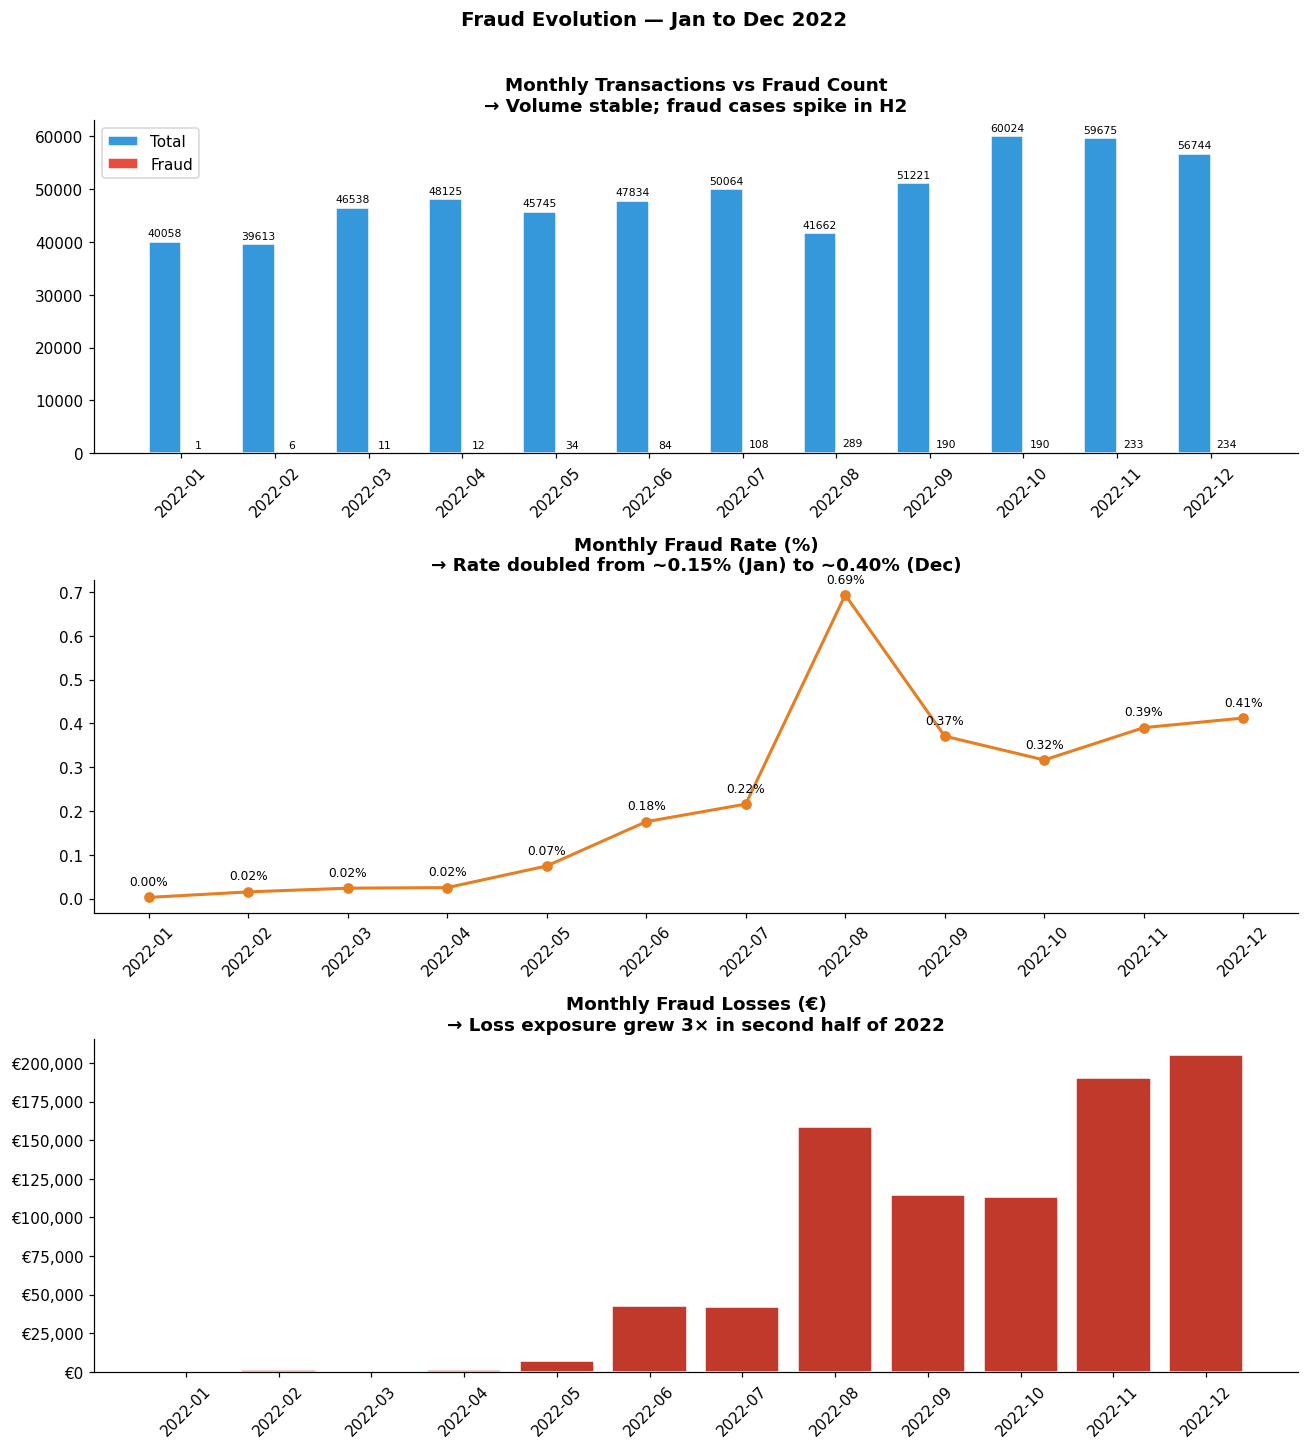

In [24]:
df_monthly = (
    df.groupby('time_settled_month')
    .agg(
        txn_count   = ('is_fraud', 'size'),
        fraud_count = ('is_fraud', 'sum'),
        fraud_losses= ('movement_amount_euros_abs',
                       lambda x: x[df.loc[x.index,'is_fraud']==1].sum()),
    )
)
df_monthly['fraud_rate'] = df_monthly['fraud_count'] / df_monthly['txn_count'] * 100
months = df_monthly.index.astype(str)

fig, axes = plt.subplots(3, 1, figsize=(12, 13))

# (a) volume vs fraud count
ax = axes[0]
x = np.arange(len(months)); w = 0.35
b1 = ax.bar(x-w/2, df_monthly['txn_count'],   w, label='Total',  color='#3498db', edgecolor='white')
b2 = ax.bar(x+w/2, df_monthly['fraud_count'],  w, label='Fraud',  color='#e74c3c', edgecolor='white')
ax.bar_label(b1, fmt='%d', fontsize=7, padding=2)
ax.bar_label(b2, fmt='%d', fontsize=7, padding=2)
ax.set_xticks(x); ax.set_xticklabels(months, rotation=45)
ax.set_title('Monthly Transactions vs Fraud Count\n→ Volume stable; fraud cases spike in H2', fontweight='bold')
ax.legend()

# (b) fraud rate
ax = axes[1]
ax.plot(months, df_monthly['fraud_rate'], marker='o', color='#e67e22', linewidth=2)
for i, v in enumerate(df_monthly['fraud_rate']):
    ax.annotate(f'{v:.2f}%', (months[i], v), textcoords='offset points',
                xytext=(0,8), ha='center', fontsize=8)
ax.set_title('Monthly Fraud Rate (%)\n→ Rate doubled from ~0.15% (Jan) to ~0.40% (Dec)', fontweight='bold')
ax.tick_params(axis='x', rotation=45)

# (c) fraud losses
ax = axes[2]
ax.bar(months, df_monthly['fraud_losses'], color='#c0392b', edgecolor='white')
ax.set_title('Monthly Fraud Losses (€)\n→ Loss exposure grew 3× in second half of 2022', fontweight='bold')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))

plt.suptitle('Fraud Evolution — Jan to Dec 2022', fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4 — EDA: Feature Distributions vs Fraud

### 4.1 Numerical features

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/3274788019.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df.loc[df['is_fraud']==0, col].dropna(),
/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/3274788019.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df.loc[df['is_fraud']==0, col].dropna(),
/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/3274788019.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([df.loc[df['is_fraud']==0, col].dropna(),


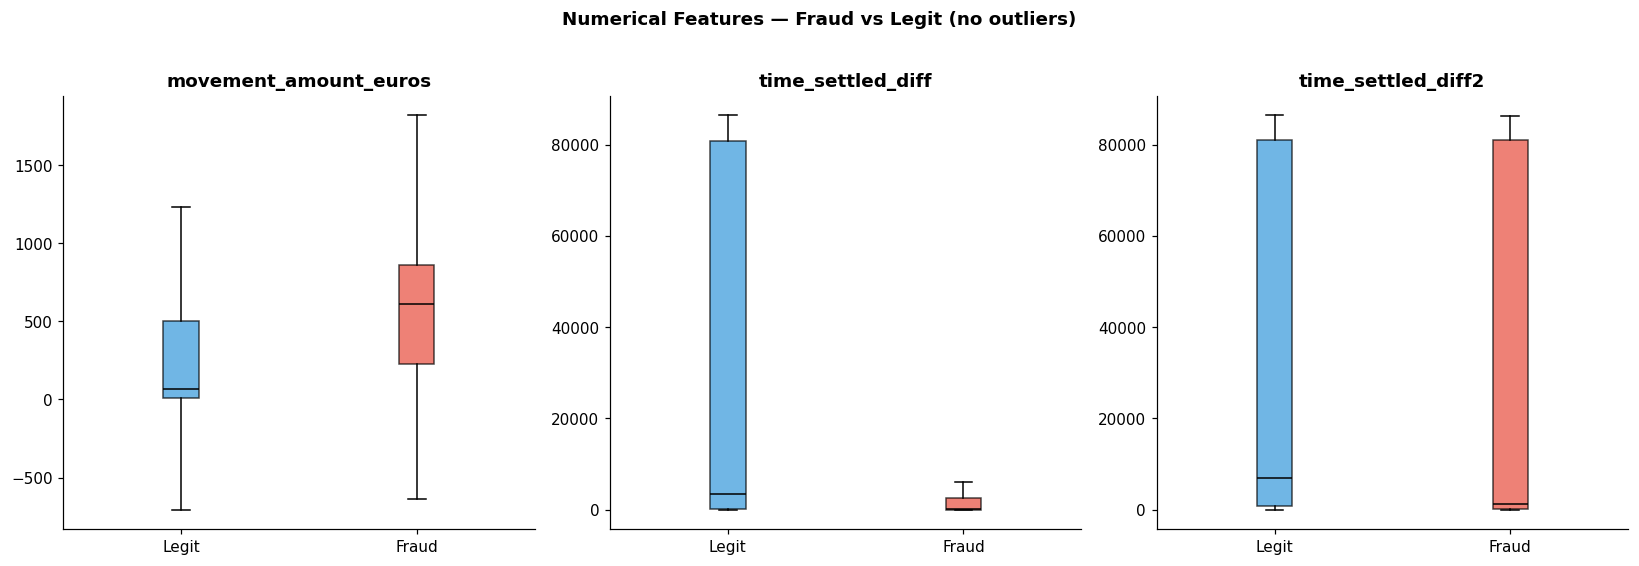

In [25]:
numerical_cols = ['movement_amount_euros', 'time_settled_diff', 'time_settled_diff2']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col in zip(axes, numerical_cols):
    for label, color, name in [(0,'#3498db','Legit'),(1,'#e74c3c','Fraud')]:
        data = df.loc[df['is_fraud']==label, col].dropna()
        bp = ax.boxplot([df.loc[df['is_fraud']==0, col].dropna(),
                         df.loc[df['is_fraud']==1, col].dropna()],
                        labels=['Legit','Fraud'], patch_artist=True,
                        showfliers=False, medianprops=dict(color='black'))
        break
    for patch, color in zip(bp['boxes'], ['#3498db','#e74c3c']):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.set_title(col, fontweight='bold')
plt.suptitle('Numerical Features — Fraud vs Legit (no outliers)', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

### 4.2 Categorical features — fraud rate & average loss

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


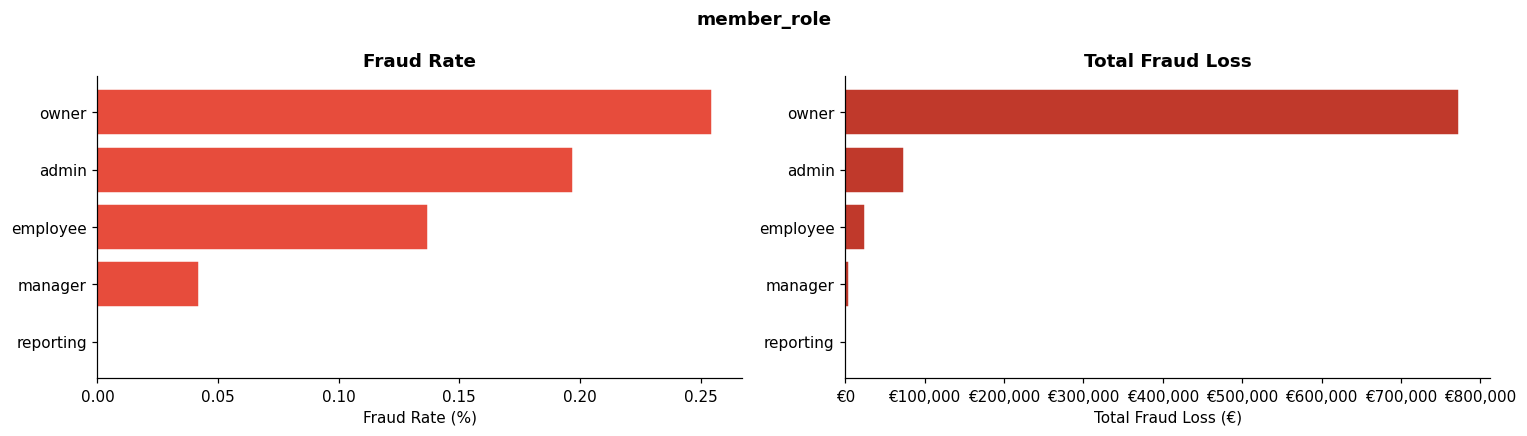

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


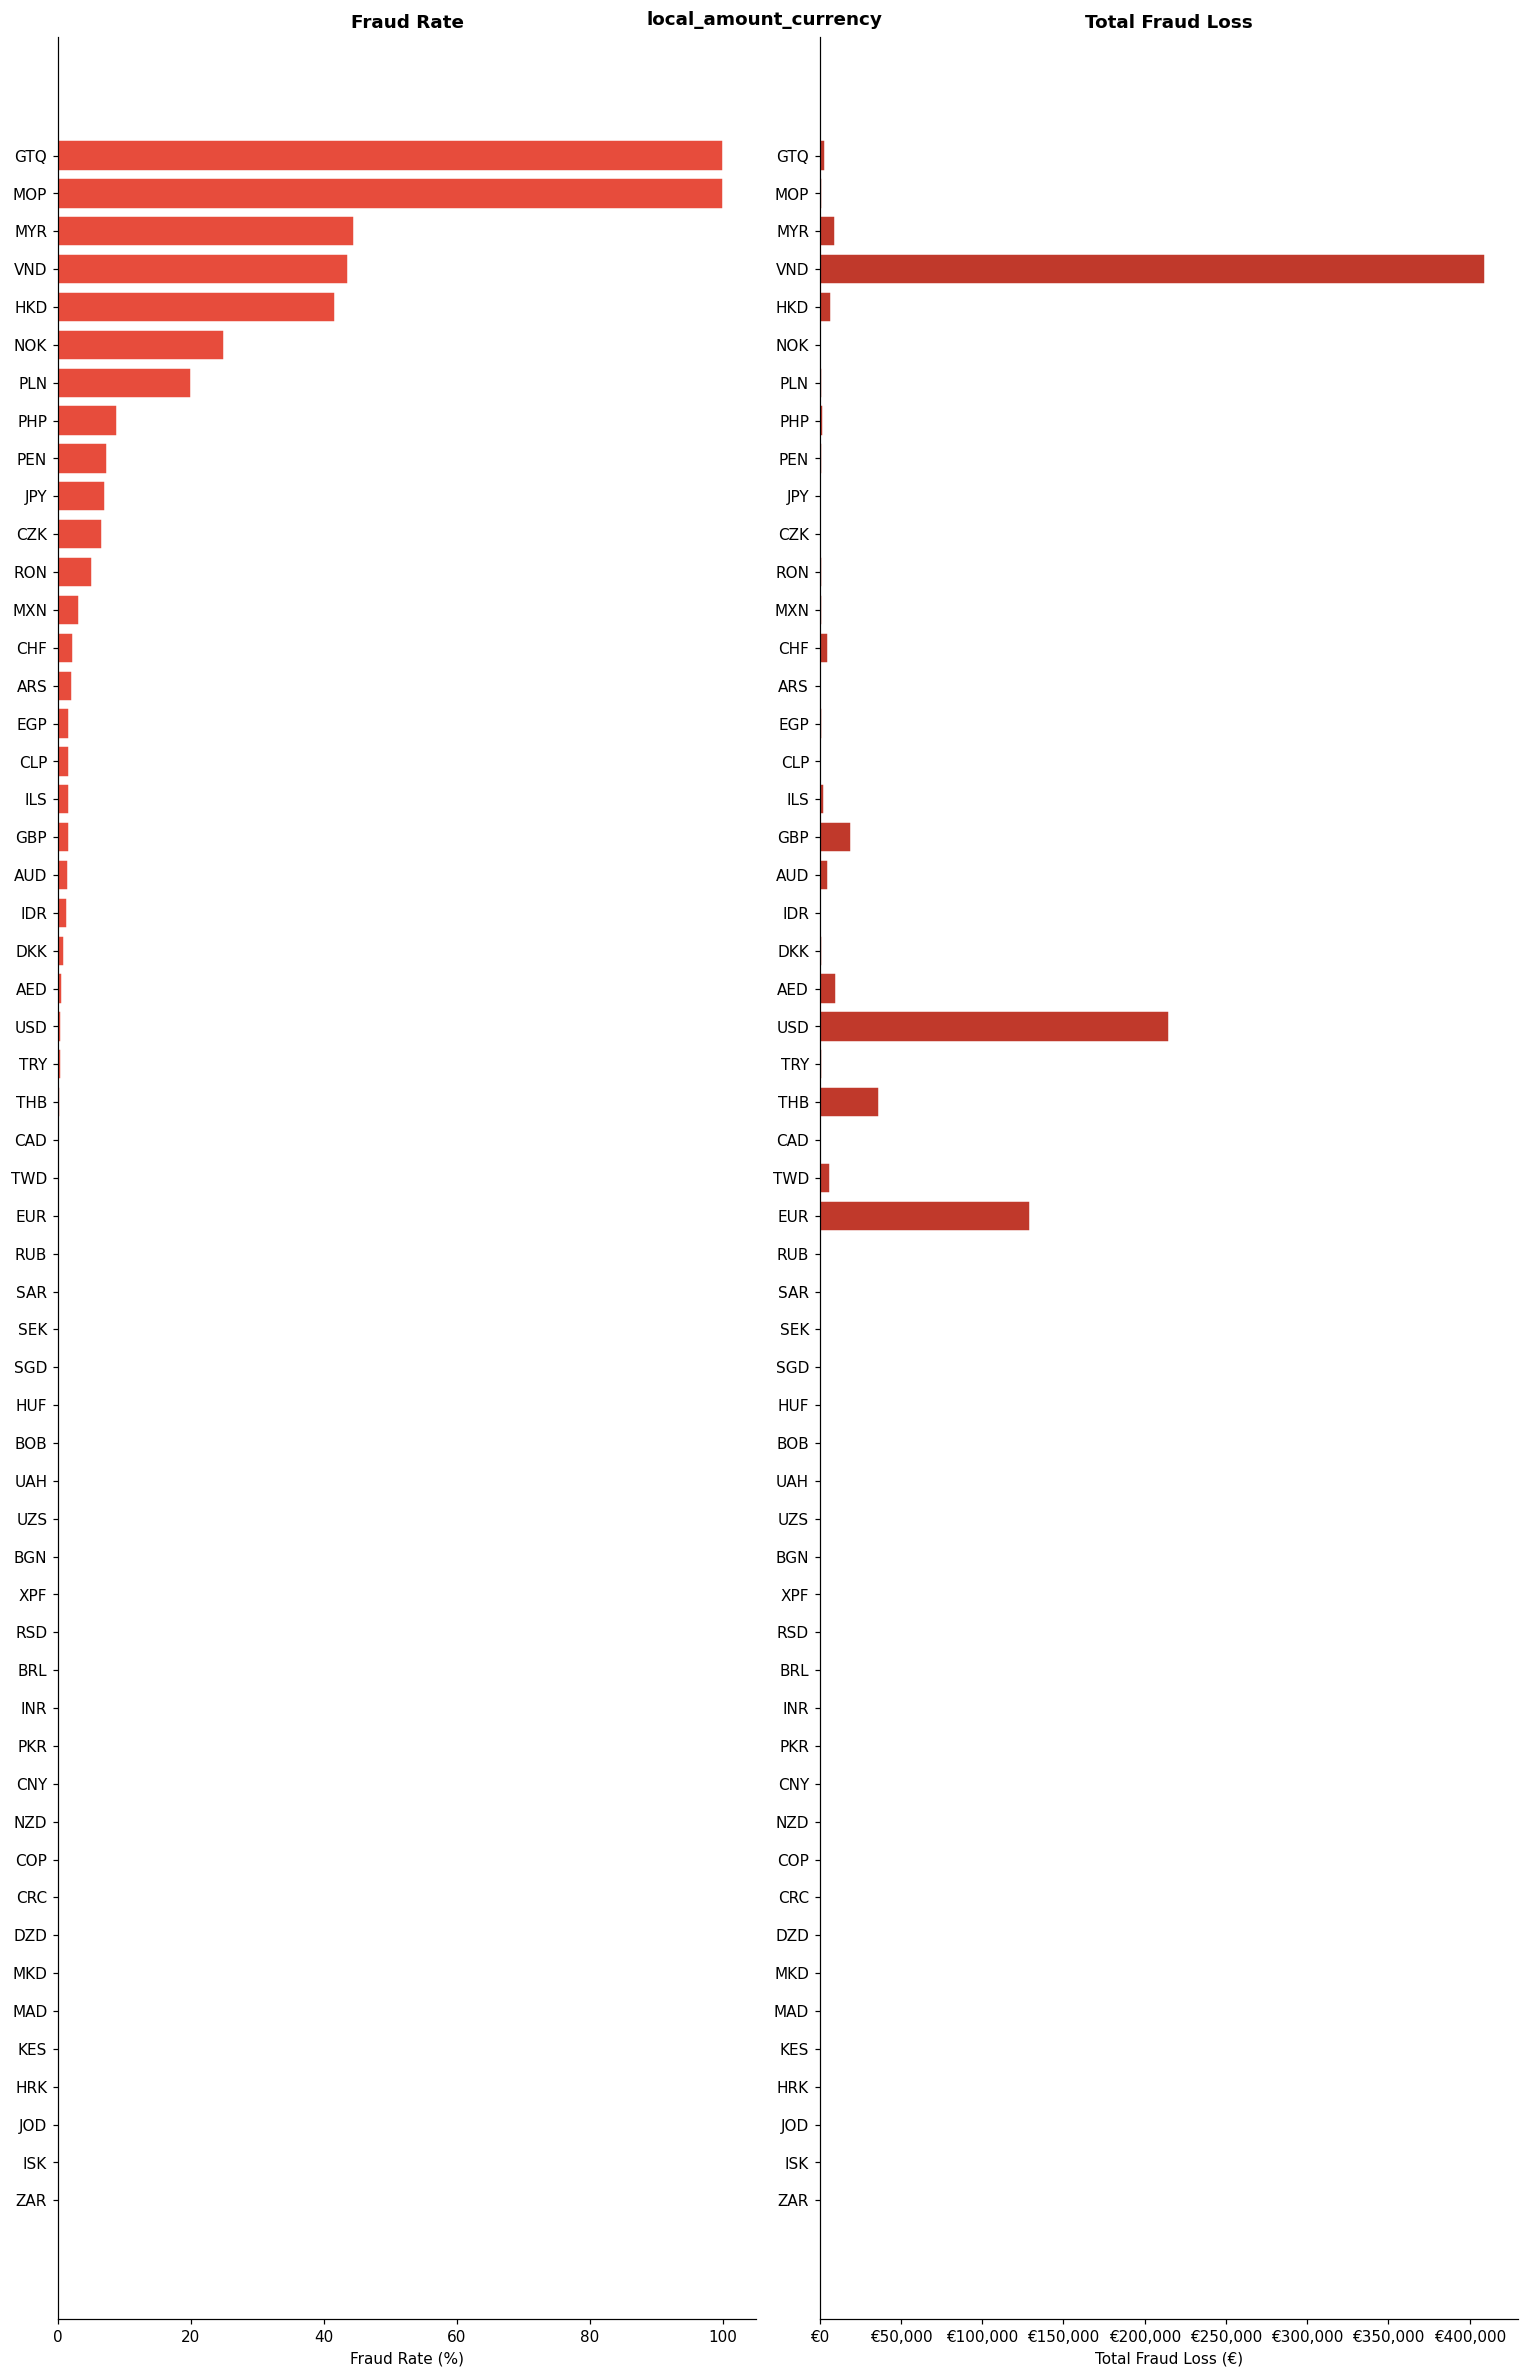

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


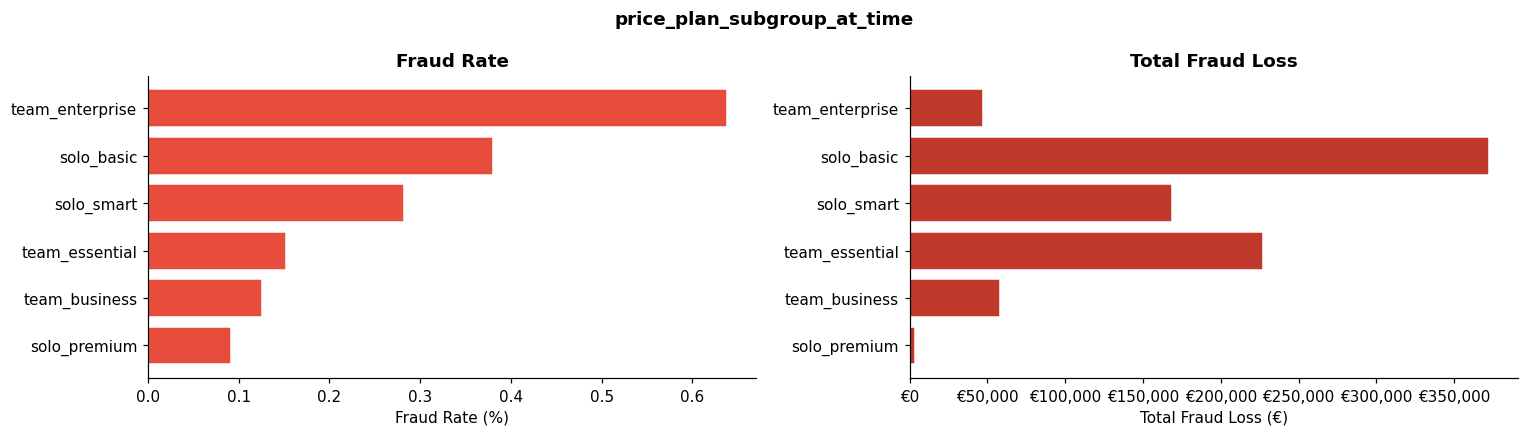

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


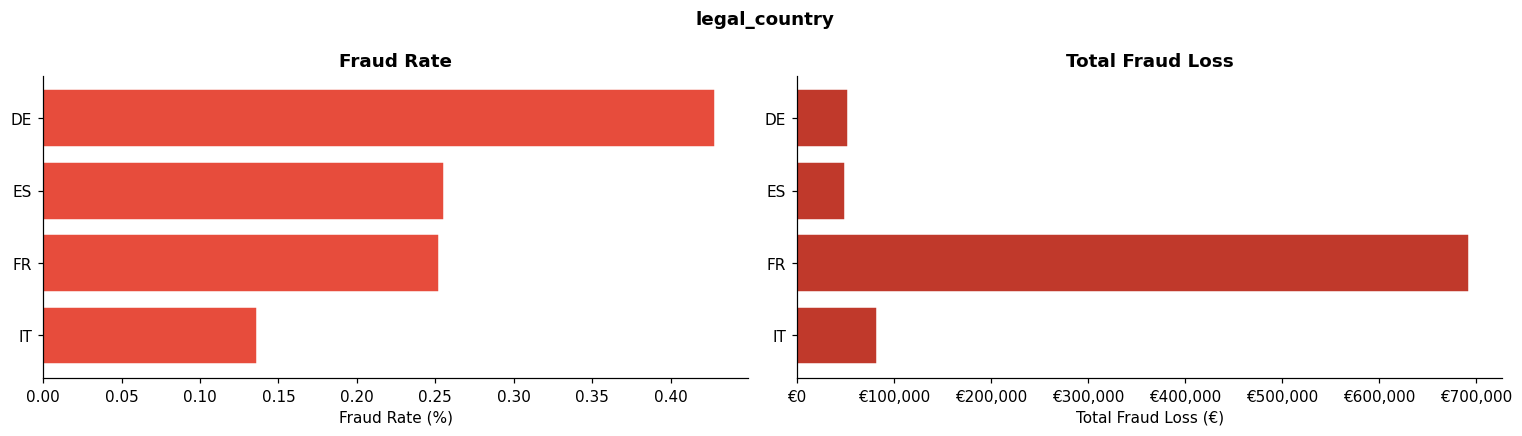

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


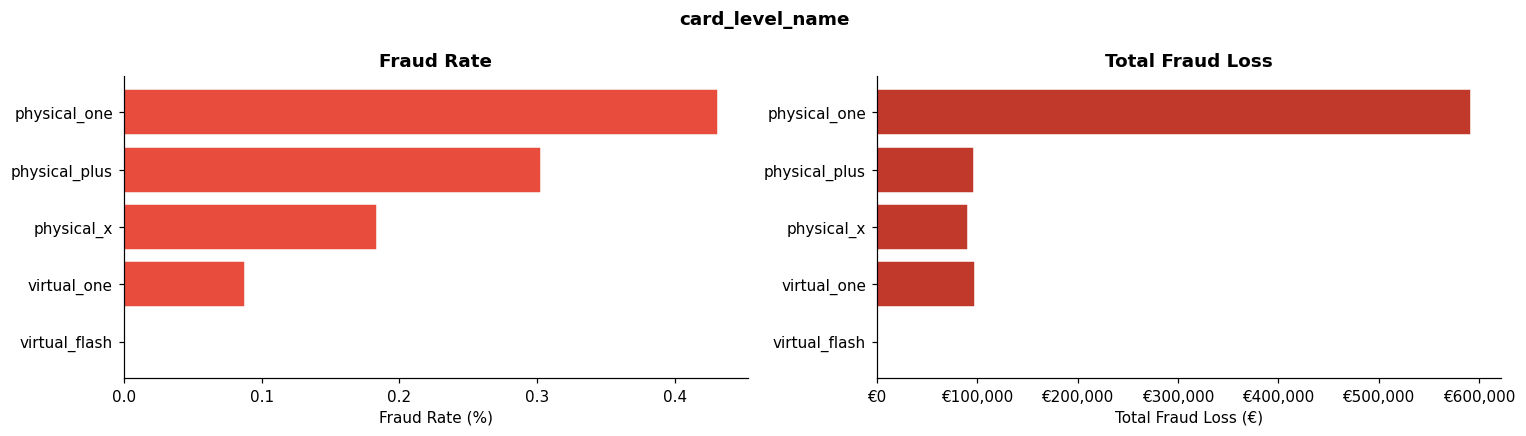

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


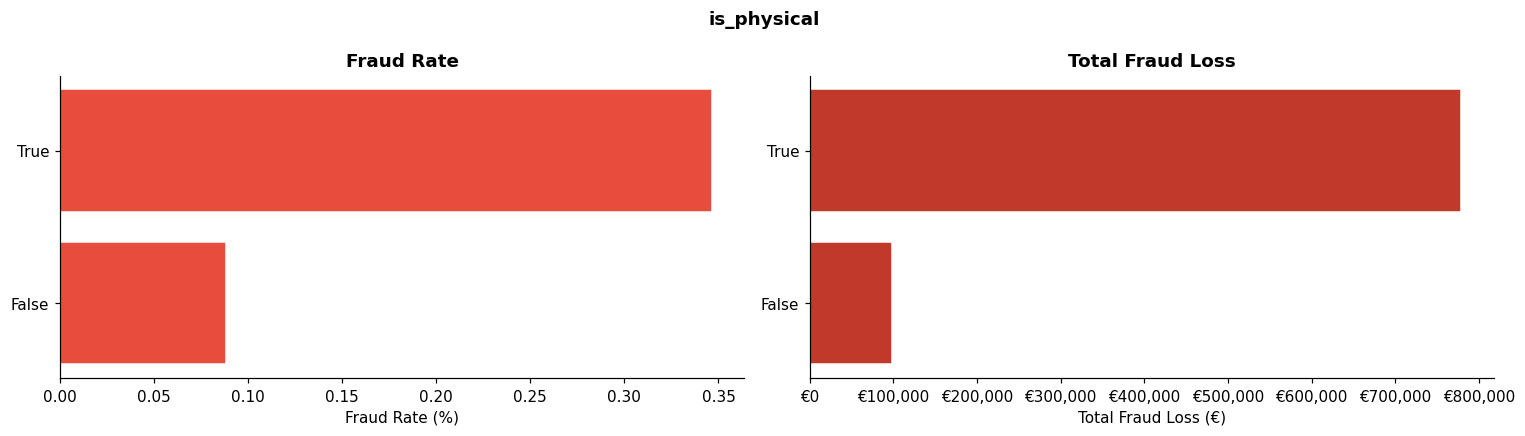

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


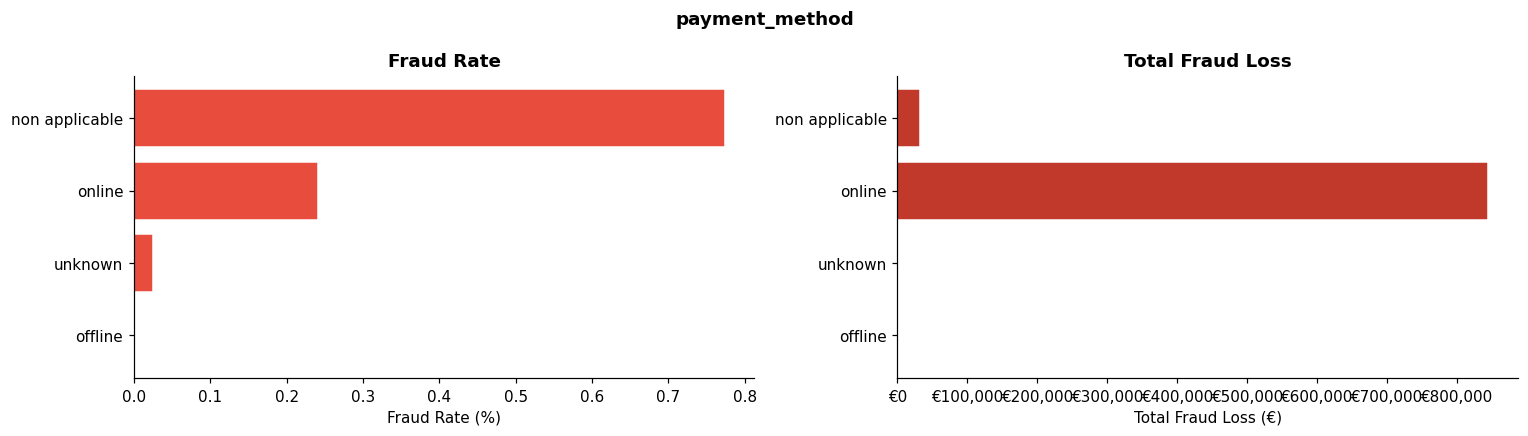

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


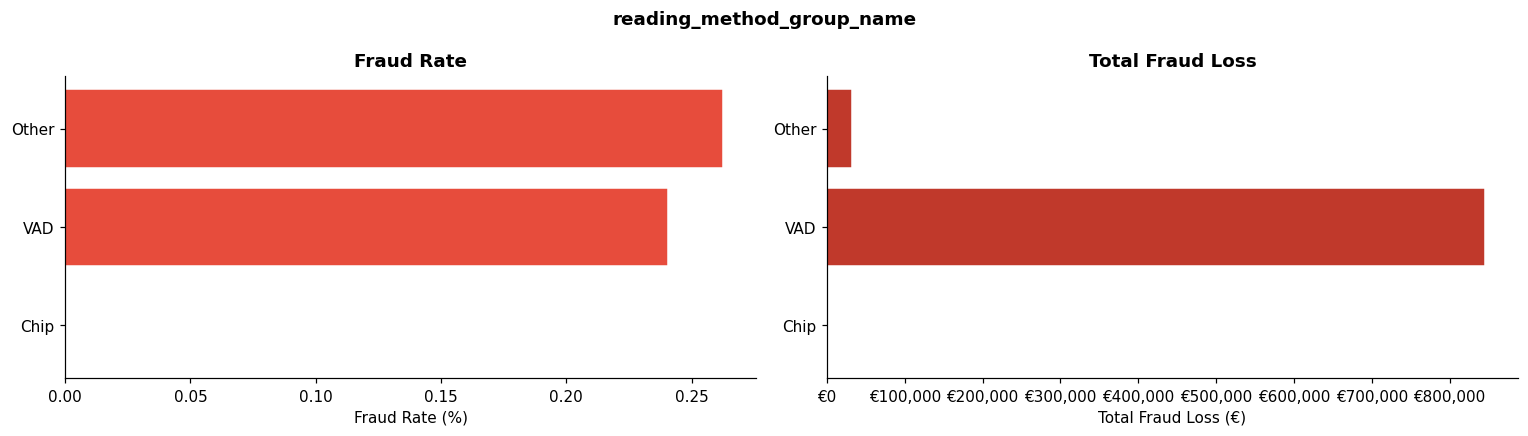

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


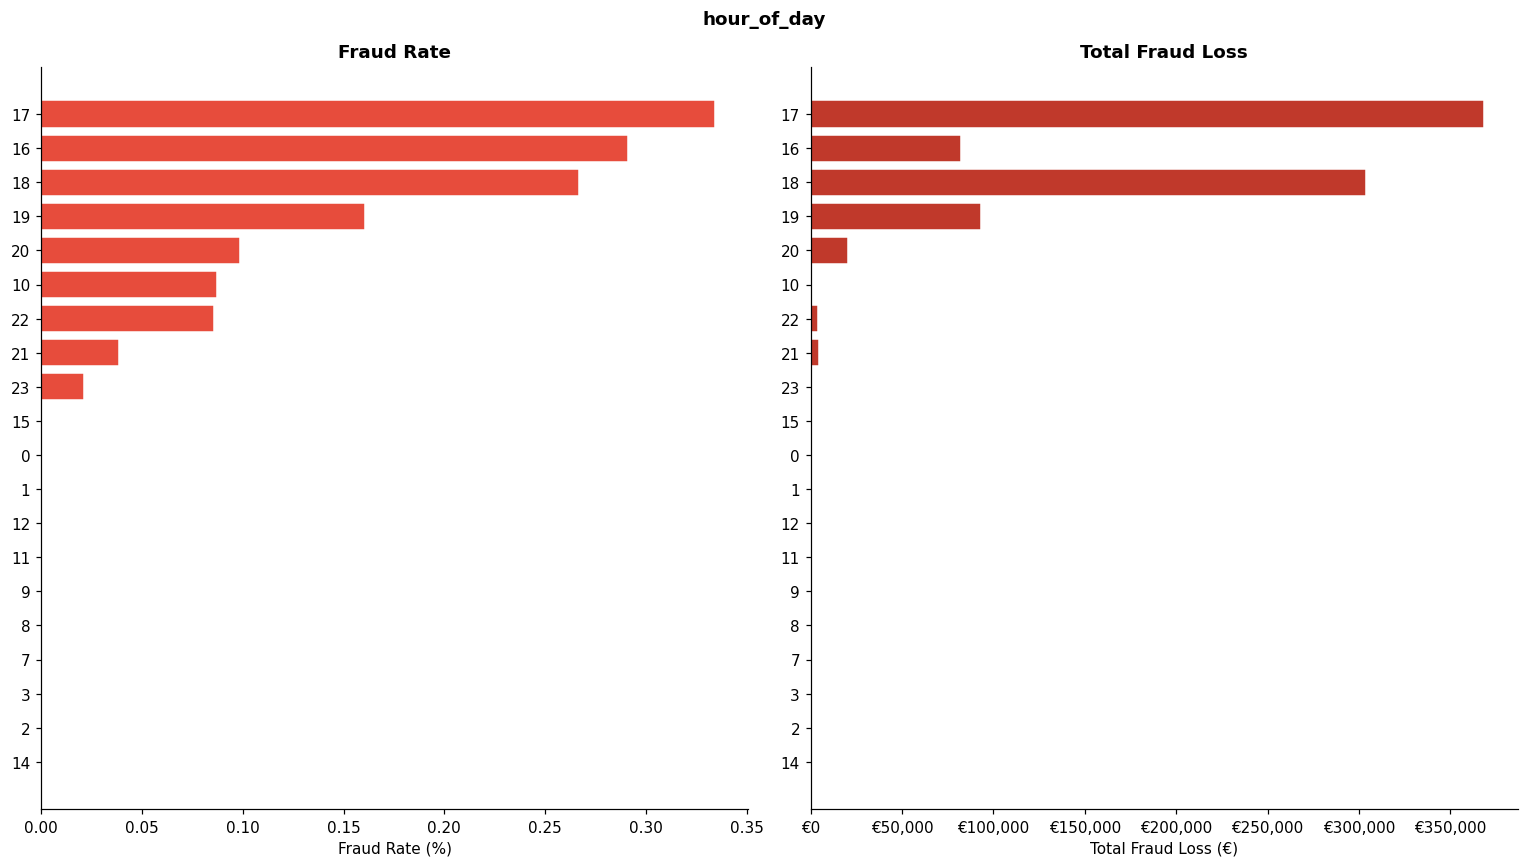

/var/folders/9b/63hbbb794vg3yf4nw7kfvybh0000gp/T/ipykernel_86191/1353432005.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats['fraud_loss'] = grp.apply(


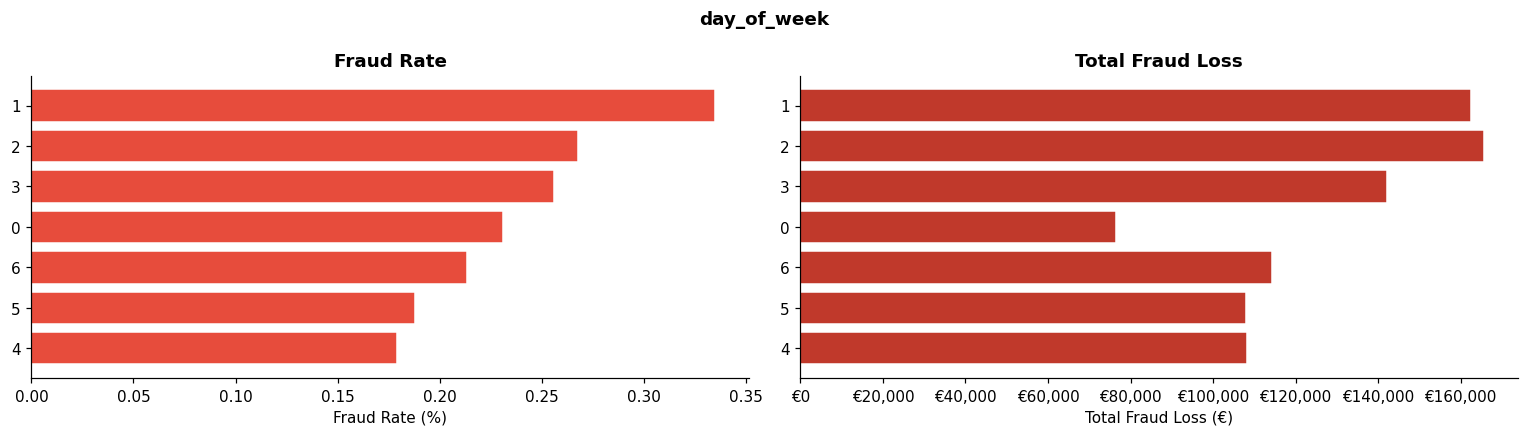

In [26]:
categorical_cols = [
    'member_role','local_amount_currency','price_plan_subgroup_at_time',
    'legal_country','card_level_name','is_physical',
    'payment_method','reading_method_group_name','hour_of_day','day_of_week'
]

for col in categorical_cols:
    grp = df.groupby(col)
    stats = grp['is_fraud'].agg(['sum','mean','size']).rename(
        columns={'sum':'fraud_count','mean':'fraud_rate','size':'txn_count'})
    stats['fraud_loss'] = grp.apply(
        lambda g: g.loc[g['is_fraud']==1,'movement_amount_euros_abs'].sum())
    stats['fraud_rate_pct'] = stats['fraud_rate'] * 100
    stats = stats.sort_values('fraud_rate_pct', ascending=False)
    labels = [str(l) for l in stats.index]

    fig, axes = plt.subplots(1, 2, figsize=(14, max(4, len(labels)*0.4)))
    axes[0].barh(labels, stats['fraud_rate_pct'], color='#e74c3c', edgecolor='white')
    axes[0].set_xlabel('Fraud Rate (%)'); axes[0].set_title('Fraud Rate', fontweight='bold')
    axes[0].invert_yaxis()

    axes[1].barh(labels, stats['fraud_loss'], color='#c0392b', edgecolor='white')
    axes[1].set_xlabel('Total Fraud Loss (€)'); axes[1].set_title('Total Fraud Loss', fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'€{x:,.0f}'))

    fig.suptitle(f'{col}', fontweight='bold', fontsize=12)
    plt.tight_layout(); plt.show()

### 4.3 Temporal stability of top fraud segments

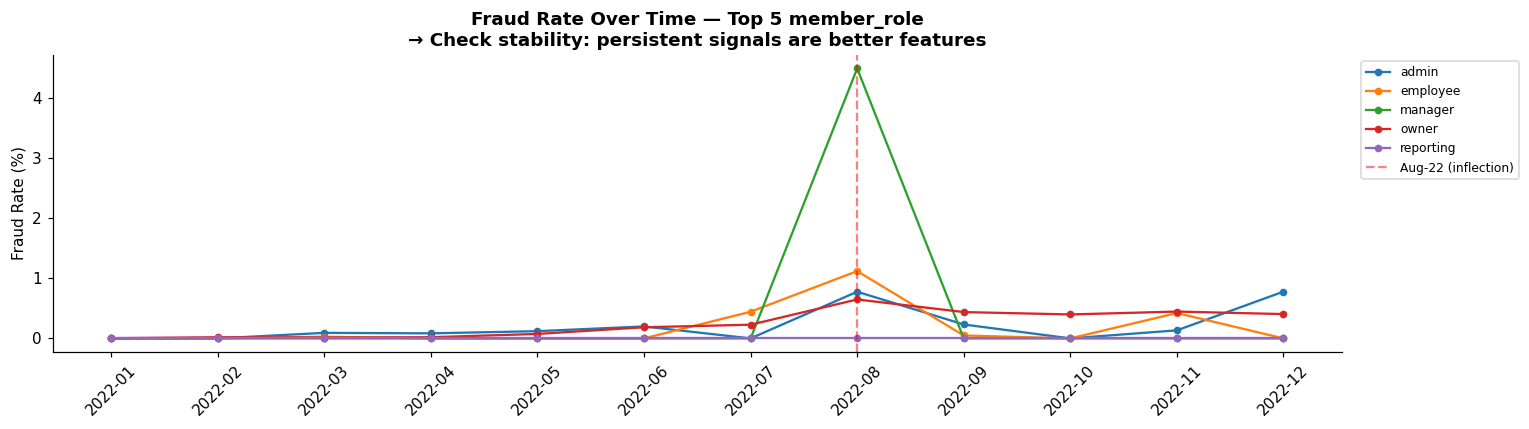

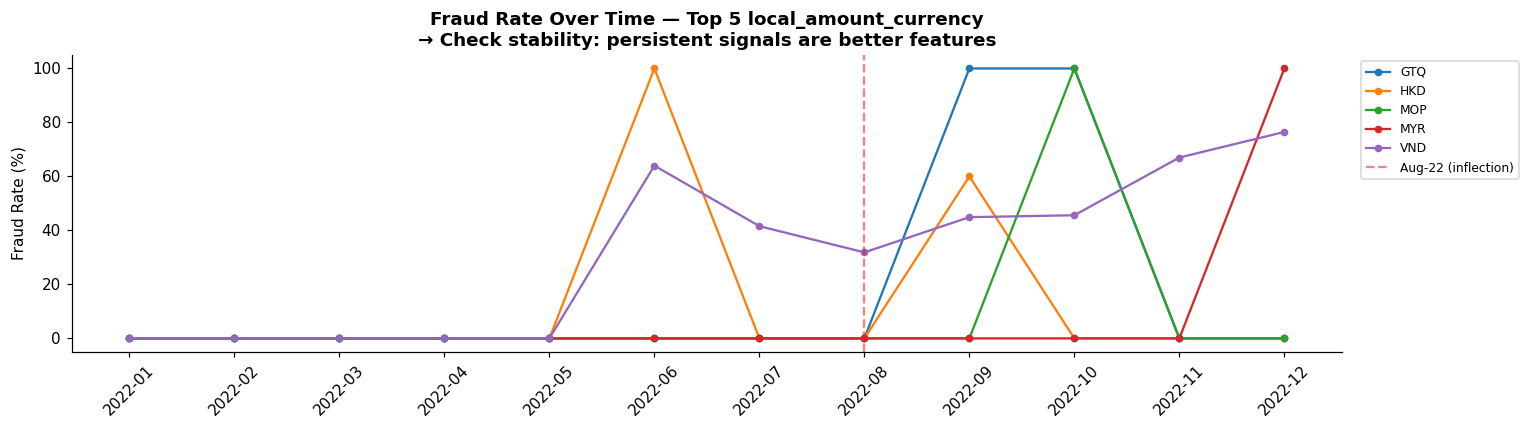

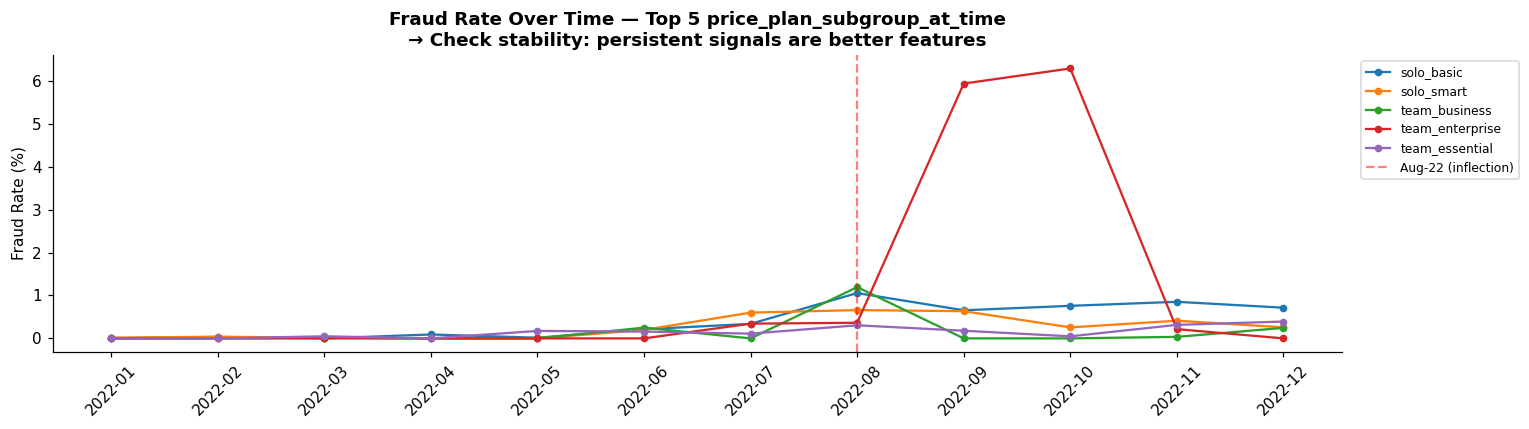

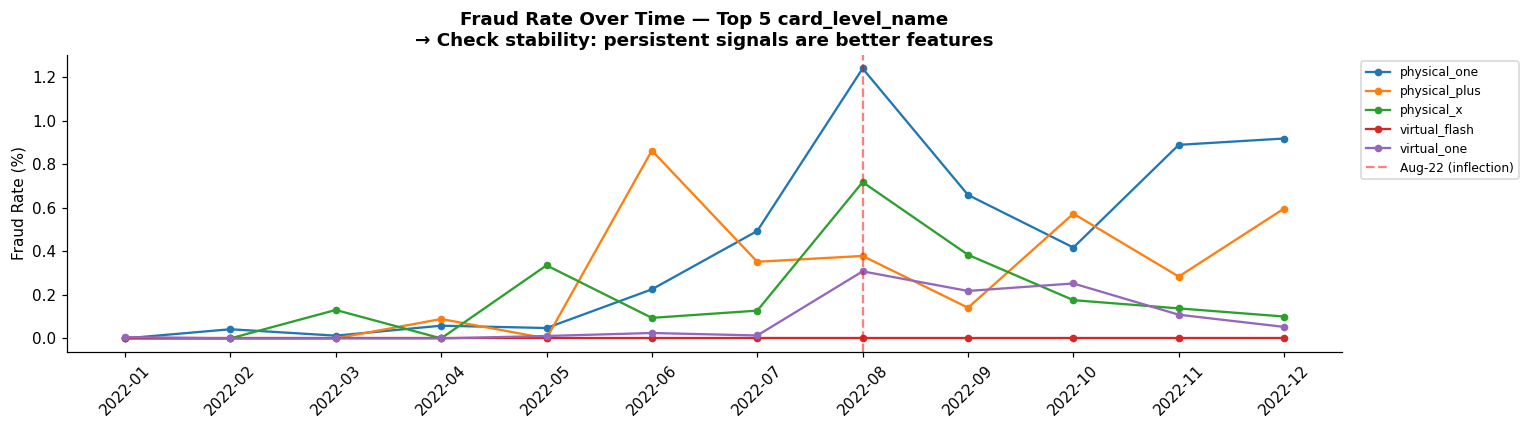

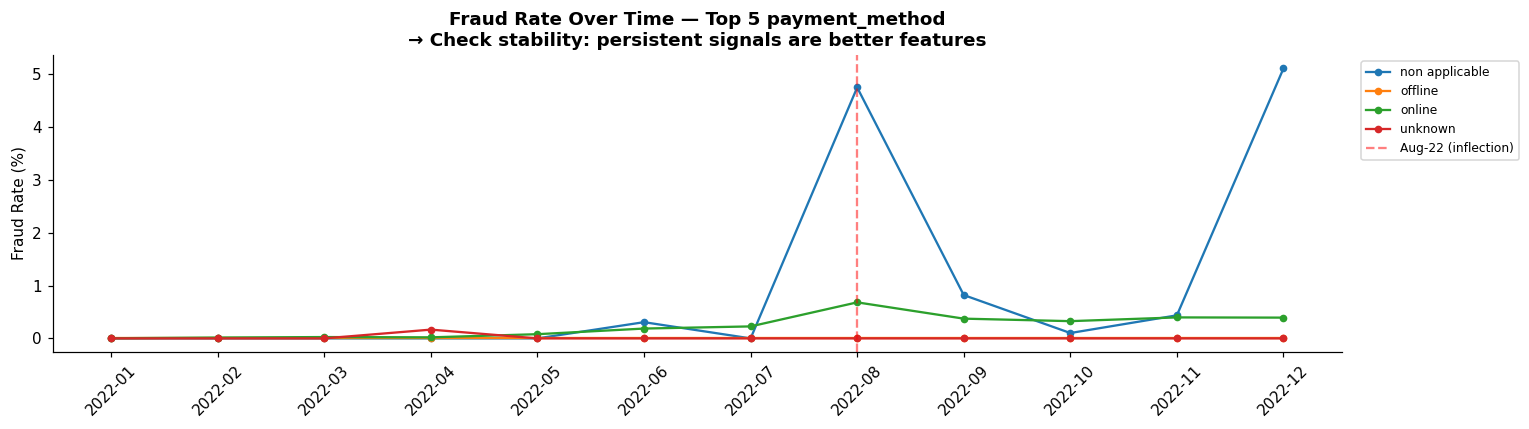

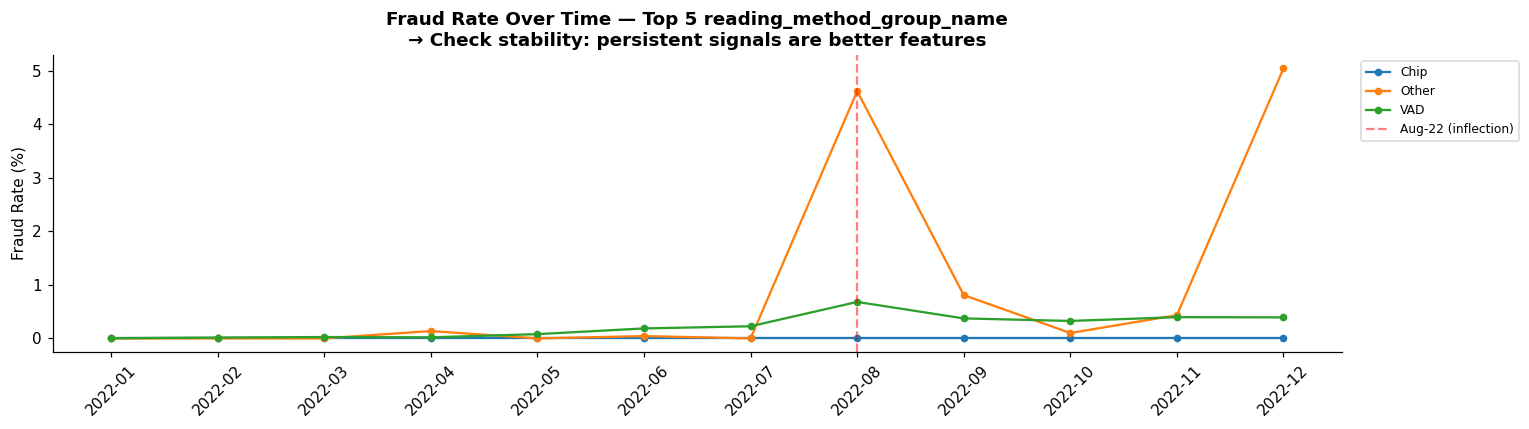

In [27]:
temporal_cols = [
    'member_role','local_amount_currency','price_plan_subgroup_at_time',
    'card_level_name','payment_method','reading_method_group_name'
]

for col in temporal_cols:
    top_vals = df.groupby(col)['is_fraud'].mean().nlargest(5).index
    subset   = df[df[col].isin(top_vals)]
    pivot    = (subset.groupby(['time_settled_month', col])['is_fraud']
                .mean().unstack(fill_value=0) * 100)
    pivot.index = pivot.index.astype(str)

    fig, ax = plt.subplots(figsize=(14, 4))
    for val in pivot.columns:
        ax.plot(pivot.index, pivot[val], marker='o', markersize=4, label=str(val))
    ax.axvline('2022-08', color='red', ls='--', alpha=0.5, label='Aug-22 (inflection)')
    ax.set_title(f'Fraud Rate Over Time — Top 5 {col}\n→ Check stability: persistent signals are better features', fontweight='bold')
    ax.set_ylabel('Fraud Rate (%)')
    ax.tick_params(axis='x', rotation=45)
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
    plt.tight_layout(); plt.show()

# Top 5 categories by fraud rate — monthly bar charts (fraud rate + txn count) Check different distributions


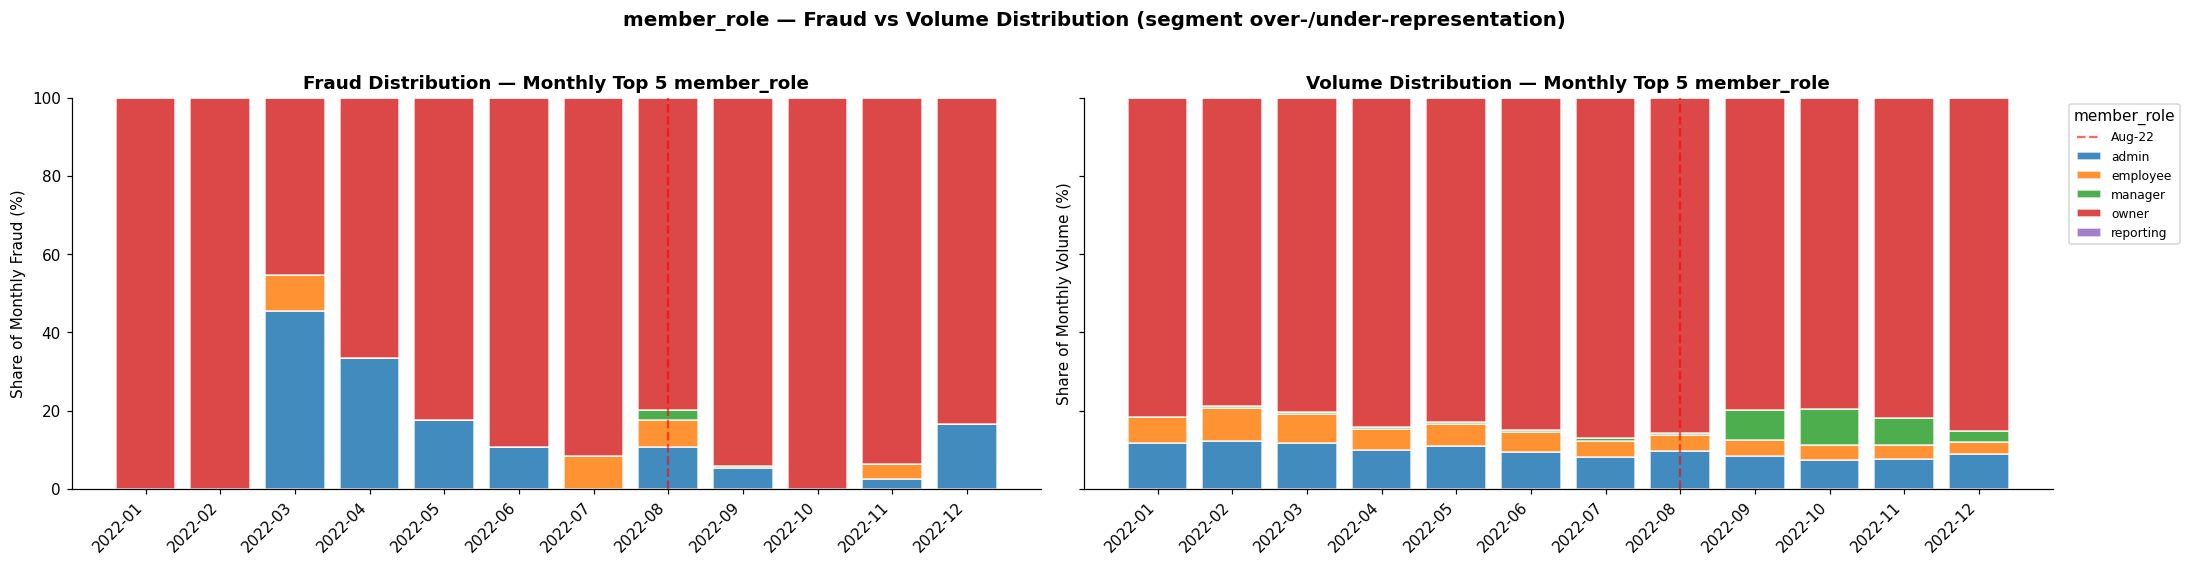

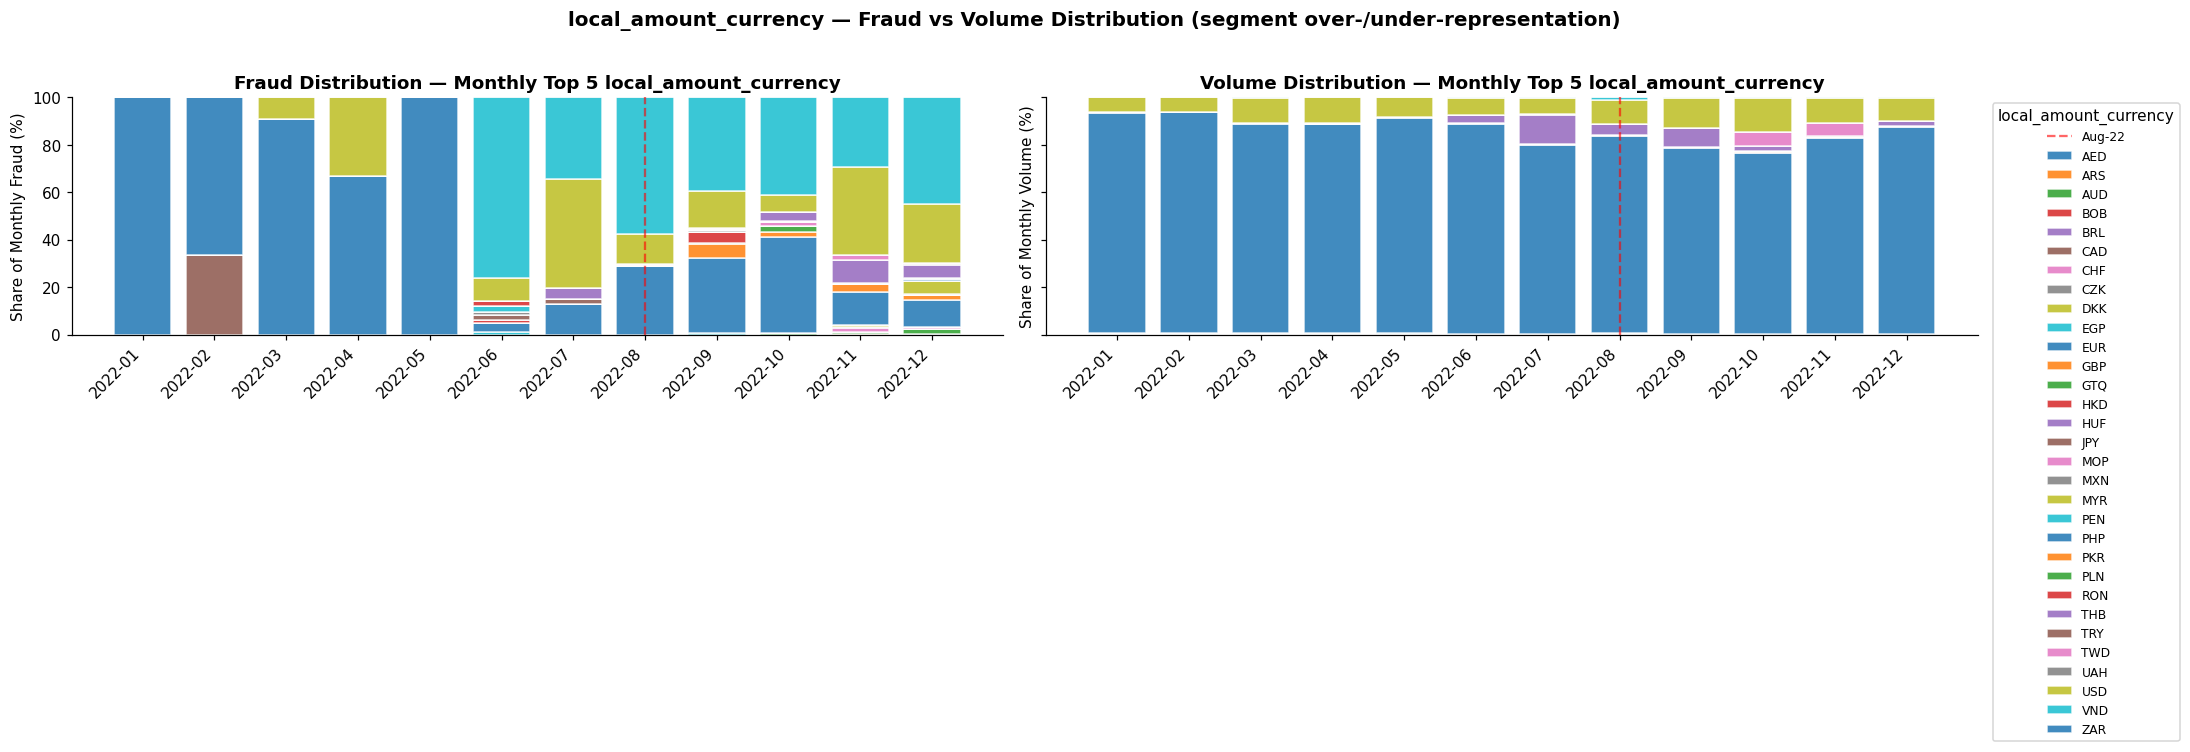

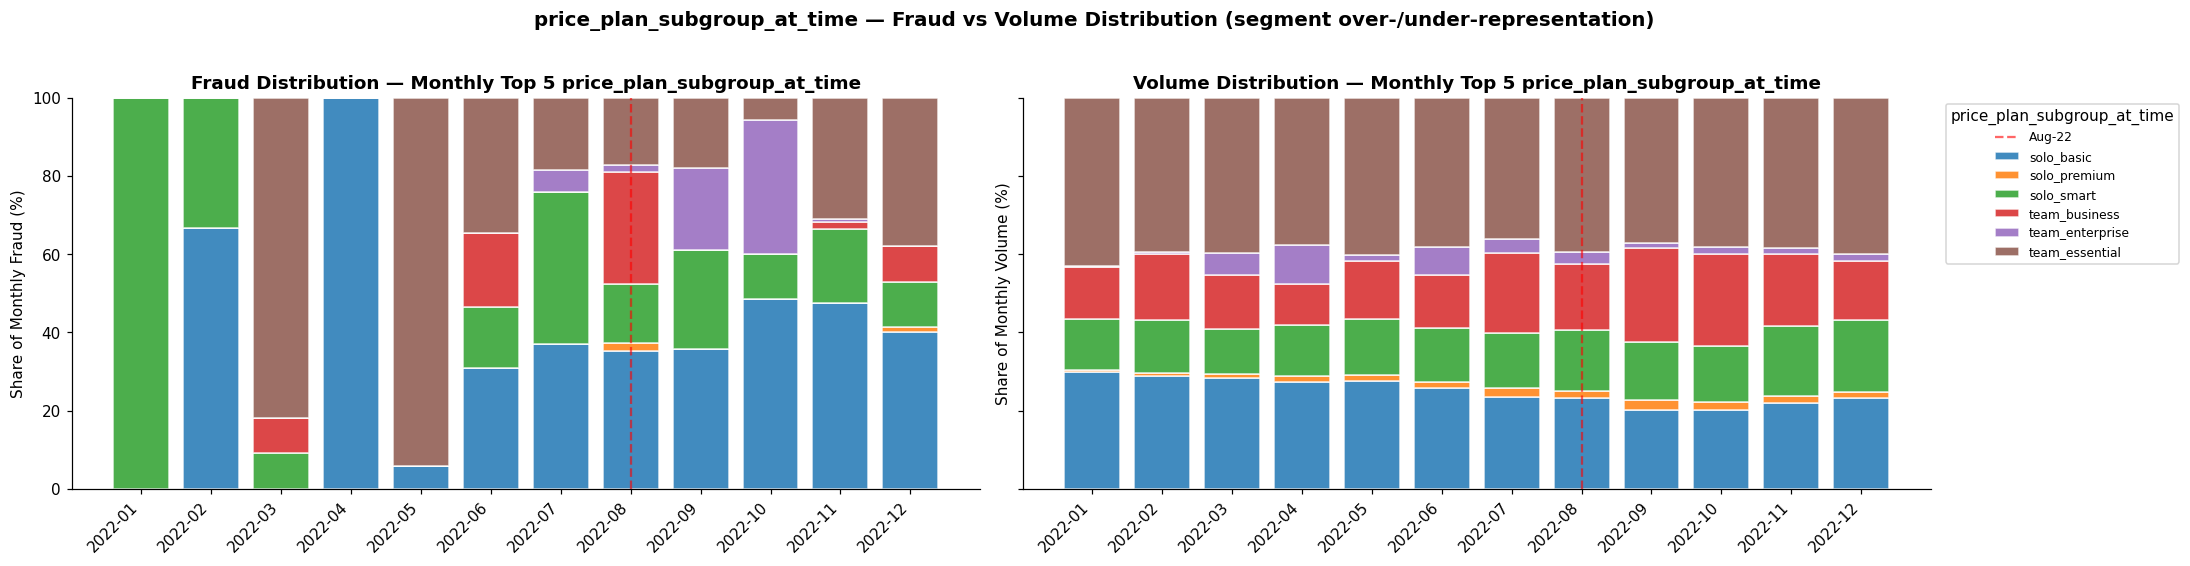

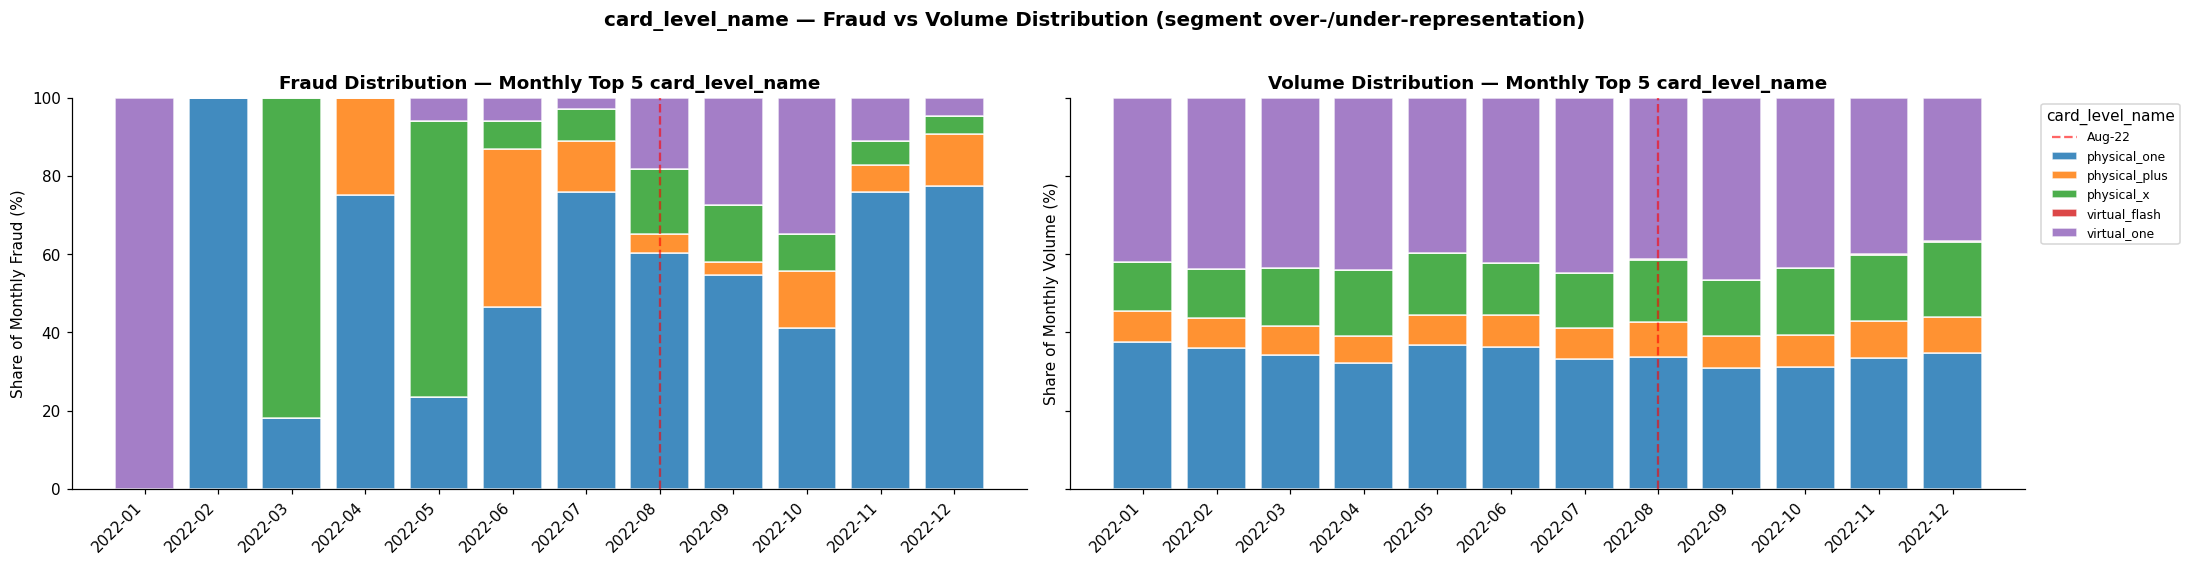

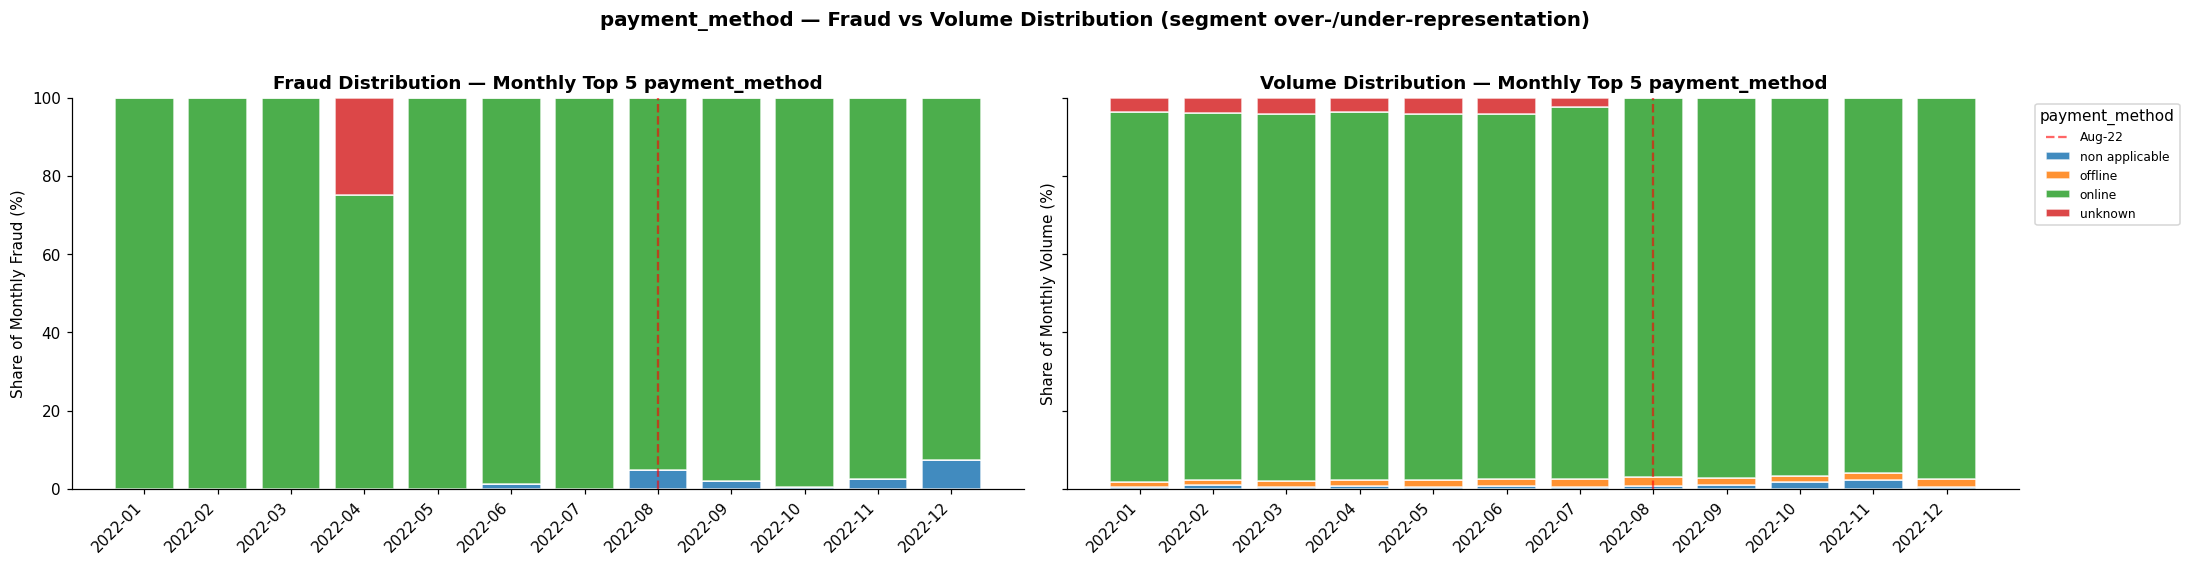

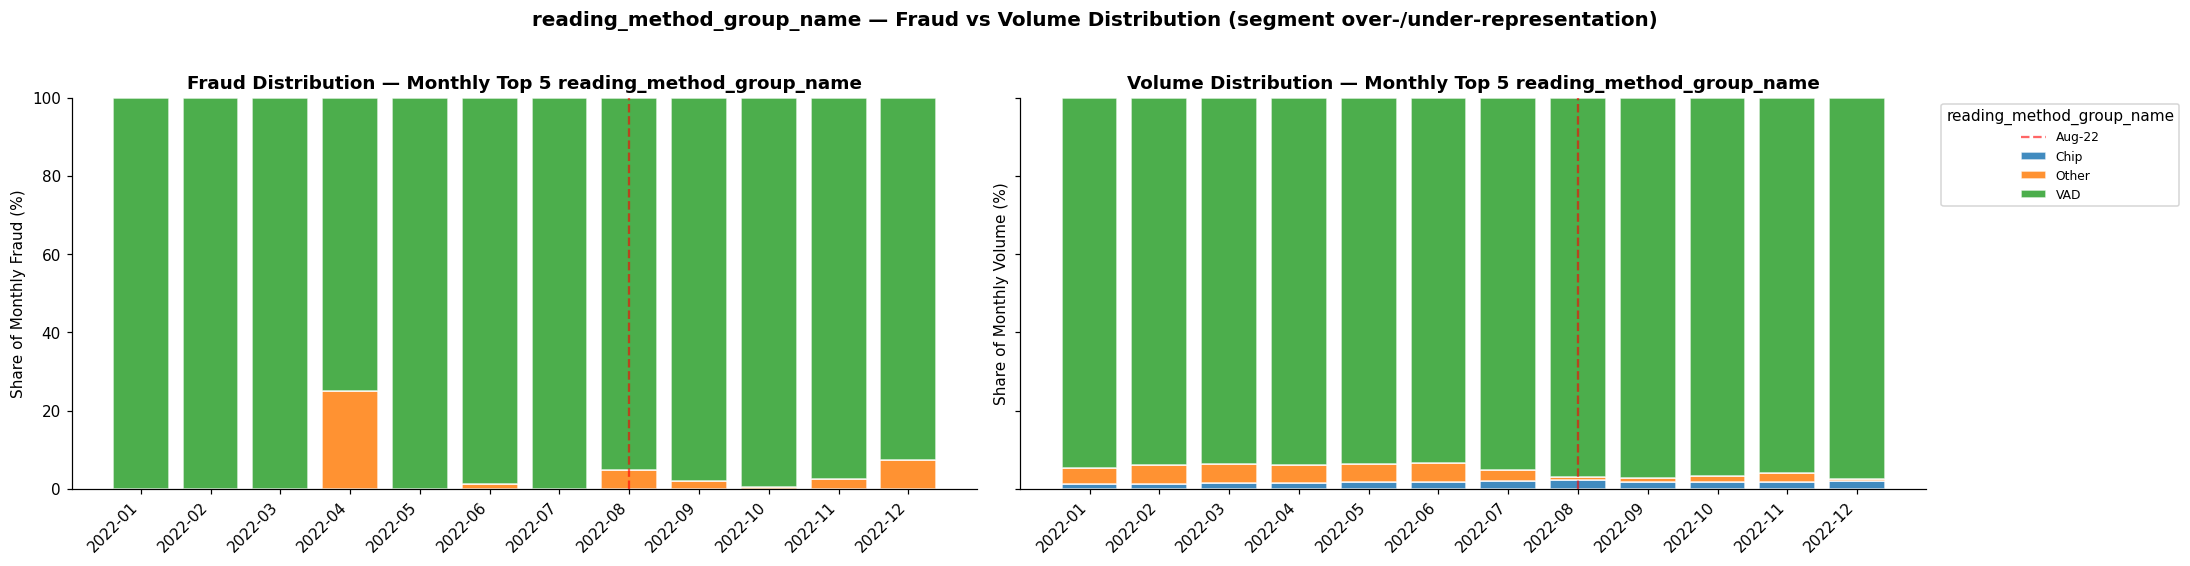

In [30]:

categorical_cols_temporal = [
    'member_role','local_amount_currency','price_plan_subgroup_at_time',
    'card_level_name','payment_method','reading_method_group_name'
]

for col in categorical_cols_temporal:
    # Top categories selected PER MONTH (union of each month's top-5 by fraud rate),
    # instead of a single global top-5 ranking.
    monthly_rate = (
        df.groupby(['time_settled_month', col])['is_fraud']
        .mean().reset_index(name='fraud_rate')
    )
    top5 = (
        monthly_rate.sort_values('fraud_rate', ascending=False)
        .groupby('time_settled_month').head(5)[col].unique()
    )
    subset = df[df[col].isin(top5)]

    # Compare two distributions per month: share of FRAUD vs share of VOLUME across the same top segments.
    # Where a segment's fraud share > its volume share => over-represented in fraud (risk signal).
    pivot_fraud = (
        subset.groupby(['time_settled_month', col])['is_fraud']
        .sum().unstack(fill_value=0)
    )
    pivot_vol = (
        subset.groupby(['time_settled_month', col])['is_fraud']
        .size().unstack(fill_value=0)
        .reindex(columns=pivot_fraud.columns, fill_value=0)
    )
    fraud_share = pivot_fraud.div(pivot_fraud.sum(axis=1), axis=0).fillna(0) * 100
    vol_share   = pivot_vol.div(pivot_vol.sum(axis=1), axis=0).fillna(0) * 100
    for p in [fraud_share, vol_share]:
        p.index = p.index.astype(str)

    months = fraud_share.index.tolist()
    x = np.arange(len(months))
    colors = plt.cm.tab10.colors

    fig, axes = plt.subplots(1, 2, figsize=(20, 5), sharey=True)

    # (a) Distribution of FRAUD across top segments
    ax = axes[0]
    bottom = np.zeros(len(months))
    for idx, val in enumerate(fraud_share.columns):
        ax.bar(x, fraud_share[val], 0.8, bottom=bottom,
               label=str(val), color=colors[idx % 10], alpha=0.85, edgecolor='white')
        bottom += fraud_share[val].values
    if '2022-08' in months:
        ax.axvline(x=months.index('2022-08'), color='red', linestyle='--', alpha=0.6, label='Aug-22')
    ax.set_xticks(x)
    ax.set_xticklabels(months, rotation=45, ha='right')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Share of Monthly Fraud (%)')
    ax.set_title(f'Fraud Distribution — Monthly Top 5 {col}', fontweight='bold')

    # (b) Distribution of VOLUME (exposure) across the same segments
    ax = axes[1]
    bottom = np.zeros(len(months))
    for idx, val in enumerate(vol_share.columns):
        ax.bar(x, vol_share[val], 0.8, bottom=bottom,
               label=str(val), color=colors[idx % 10], alpha=0.85, edgecolor='white')
        bottom += vol_share[val].values
    if '2022-08' in months:
        ax.axvline(x=months.index('2022-08'), color='red', linestyle='--', alpha=0.6, label='Aug-22')
    ax.set_xticks(x)
    ax.set_xticklabels(months, rotation=45, ha='right')
    ax.set_ylim(0, 100)
    ax.set_ylabel('Share of Monthly Volume (%)')
    ax.set_title(f'Volume Distribution — Monthly Top 5 {col}', fontweight='bold')
    ax.legend(title=col, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

    plt.suptitle(f'{col} — Fraud vs Volume Distribution (segment over-/under-representation)', fontweight='bold', fontsize=13, y=1.02)
    plt.tight_layout()
    plt.show()
